In [1]:
# import packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import xarray as xr
import flowkit as fk
import glob
import os
import math
from scipy.stats import linregress, ttest_ind, f_oneway, pearsonr

%matplotlib ipympl

In [2]:
# set parameters for plots/visualization
SMALL_SIZE = 7
MEDIUM_SIZE = 7
BIGGER_SIZE = 7

plt.rcParams['svg.fonttype'] = 'none'    # makes text editable in exported .svg files
plt.rcParams['font.sans-serif'] = 'Arial'# set font for all plots to Arial

plt.rc('font', family='Arial')
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# load data
data = pd.concat([pd.read_csv(f) for f in glob.glob('./*.csv')])
data = data.set_index(list('ESR')+['CellID'])

In [4]:
data = data.rename(columns= {'BL1-H' : 'FITC', 'YL1-H' : 'mCherry'})

In [5]:
# thresholding (note that threshold values are calcuated from the entire data set)
tthr = data['mCherry'].xs('untransfected_unstained', level = 'S').quantile(0.995) # transfection threshold
controls = [name for name in data.index.unique('S') if ('_unstained' in name and 'untransfected' not in name) or '_-_' in name]
sthr = data['FITC'].loc[pd.IndexSlice[:,controls]].quantile(0.995) # surface stain threshold

In [6]:
# quantile binning based on all transfected cells in the dataset
transfected = data[data['mCherry'] > tthr].drop('untransfected_unstained', level = 'S') # dataframe of transfected cells
transfected = transfected[(transfected['mCherry'] > 0) & (transfected['FITC'] > 0)]
transfected['bin'], bins = pd.qcut(transfected['mCherry'], 50, retbins = True)

In [7]:
# function for calculating the bin means (FP and Ab) and linear fit parameters for subsets of data
def binning(df, bins, gpby):
    """
    Parameters
    ----------
    
    df : pd.DataFrame
        Subset of the data to split among bins.
    bins : array
        Array of values that define the edges of the bins. Has length nbins + 1.
    gpby : index level name or list of names
        'group by'; specifies which index levels to use for combining data.
        e.g. use 'list("ES")' to perform calculations separately for each experiment and sample, or
        e.g. use 'S' to aggregate all experiments together by sample.
        
    Returns
    -------
    
    binned : pd.DataFrame
        Dataframe with the information as the input df but additionally
        specifying 'bin', 'FPbin', and 'Abbin' values for each cell.
    lr : pd.DataFrame
        Dataframe containing the linear regression fit parameters.
    """
    
    if 'untransfected_unstained' in df.index.unique('S'):
        df = df.drop('untransfected_unstained', level = 'S')

    binmeans = df.groupby(gpby).apply(lambda x: x.groupby(pd.cut(x['mCherry'], bins).rename('B'), observed = False).mean()).rename(columns = {'mCherry' : 'FPbin', 'FITC' : 'Abbin'})

    lr = binmeans[binmeans['Abbin'] >= 0].groupby(gpby).apply(lambda x: linregress(np.log(x['FPbin']),np.log(x['Abbin'])))
    # Note that bins with mean Abbin values equal to or below zero are excluded from the linear fit.
    # Mean FPbin values will never be equal to or below zero because tthr is greater than zero.
    lines = pd.DataFrame(index = lr.index, columns = ['slope', 'intercept', 'r', 'p', 'stderr'])
    for k, col in enumerate(lines.columns):
        lines[col] = [lr[j][k] for j in lr.index]
        
    return binmeans, lines

In [8]:
def quickplot(subset, norm_sample = 'gC3_FL_+_stained', reorder = False, limitx = True, height = 3, width = 6.5):
    
    t = subset['mCherry'] > tthr
    s = subset['FITC'] > sthr
    
    transfected = subset[t]
    transfected = transfected[(transfected['mCherry'] > 0) & (transfected['FITC'] > 0)]
    
    sde_es = (t&s)[t].groupby(list('ES')).mean()
    sde_es.name = 'FITC'
    sde_s = (t&s)[t].groupby('S').mean()
    sde_s.name = 'FITC'

    norm = transfected['FITC'].xs(norm_sample, level = 'S').mean()
    ab_es = transfected['FITC'].groupby(list('ES')).mean()/norm
    ab_s = transfected['FITC'].groupby('S').mean()/norm

    bn_es, E_es = binning(transfected, bins, list('ES'))
    bn_s, E_s = binning(transfected, bins, 'S')
    
    if reorder:
        order = subset.index.unique('S')[reorder]
    else:
        order = subset.index.unique('S')
    
    fig, axs = plt.subplots(1,3,layout = 'constrained', figsize = (width, height), sharey = True)

    for ax, each, name, plot, top in zip(
        axs,
        [(sde_es, sde_s), (ab_es, ab_s), (E_es['slope'], E_s['slope'])],
        ['FITC', 'FITC','slope'],
        [r'$f^+$', r'$\overline{Ab}$', r'$E_{surface}$'],
        ['Stained cell fraction', r'Mean Ab$_{cell}$ signal', 'Slope of dose-response'], ):

        sns.barplot(
            data = each[1].loc[order].reset_index(),
            y = 'S',
            x = name,
            ax = ax,
            color = '#969696',
            # hue = 'S', palette = [clrd[j] for j in each[1].reset_index()['S']],
        )
        sns.swarmplot(
            data = each[0].loc[pd.IndexSlice[:,order]].reset_index(),
            y = 'S',
            x = name,
            ax = ax,
            s = 3,
            color = 'k',
        )
        ax.set_ylabel(None)
        # ax.set_yticks(ax.get_yticks(), [sample_dictionary[o] for o in each[1].loc[order].reset_index()['S']])
        ax.spines[['top','right']].set_visible(False)
        ax.set_xlabel(plot)
        ax.set_title(top)
    
#     if limitx:
#         axs[0].set_xlim(0,1)

    plt.show()
    
    return [sde_es, sde_s, ab_es, ab_s, E_es, E_s, bn_es, bn_s, transfected, t, s]

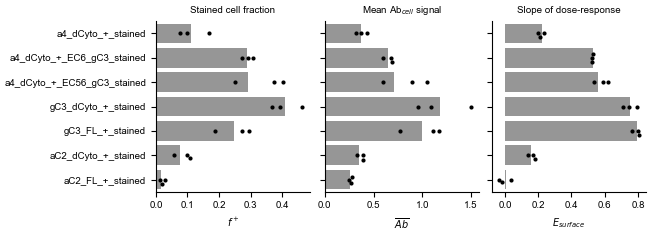

In [9]:
df = data.drop('untransfected_unstained', level = 'S')
stained_tagged = [smpl for smpl in df.index.unique('S') if '_+_' in smpl and '_stained' in smpl and not 'EC6_a4' in smpl]
stained_tagged = [stained_tagged[j] for j in [1,3,5,-1,2,4,0]]
stained = df.loc[pd.IndexSlice[:,stained_tagged,:]]
show = quickplot(stained, height = 2.3522, width = 6.5)
plt.savefig('flow_data_quickplot.svg')

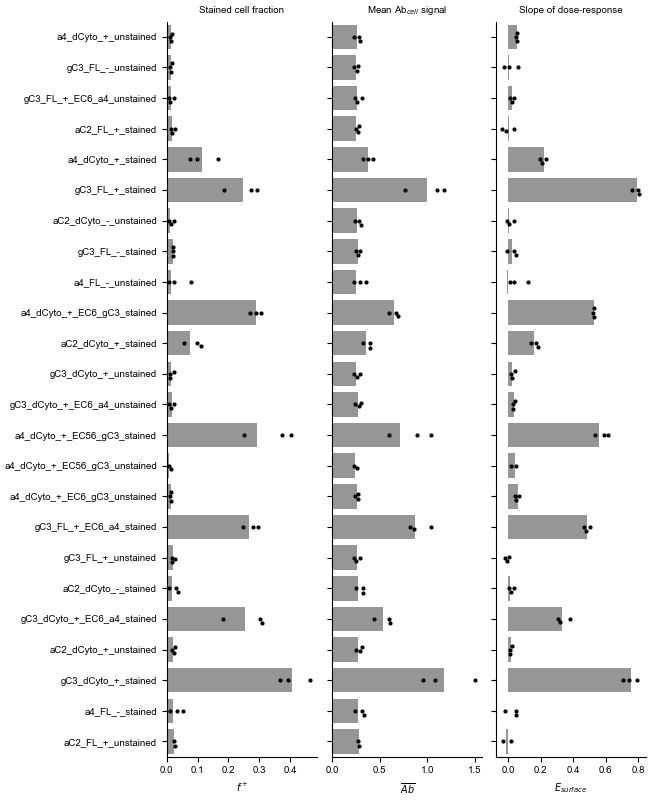

In [10]:
sde_es, sde_s, ab_es, ab_s, E_es, E_s, bn_es, bn_s, transfected, t, s = quickplot(df, height = 8)

In [11]:
from matplotlib.ticker import FixedLocator

In [12]:
def logticks(ax, xaxis = True, yaxis = True):
    
    tickrange = np.array([-100, -10, 1, 10, 100, 1000, 10000, 100000, 1000000])
    minorticks = np.array([np.arange(0,n,n/10)[1:] for n in tickrange[tickrange > 0]]).ravel()
    
    if xaxis: 
        minx, maxx = [np.e**j for j in ax.get_xlim()]
        xticks = np.array([x for x in tickrange if x > minx and x < maxx])
        ax.set_xticks(np.log(xticks), xticks)
        
        minorxticks = np.array([x for x in minorticks if x > minx and x < maxx])
        ax.xaxis.set_minor_locator(FixedLocator(np.log(minorxticks)))
        
    if yaxis:
        miny, maxy = [np.e**j for j in ax.get_ylim()]
        yticks = np.array([y for y in tickrange if y > miny and y < maxy])
        ax.set_yticks(np.log(yticks), yticks)
        
        minoryticks = np.array([y for y in minorticks if y > miny and y < maxy])
        ax.yaxis.set_minor_locator(FixedLocator(np.log(minoryticks)))

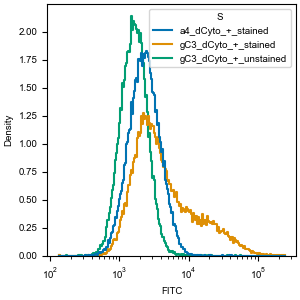

In [13]:
fig, ax = plt.subplots(1,1, layout = 'constrained', figsize = (3,3))

sns.histplot(
    data = transfected.loc[pd.IndexSlice[:,[
        'a4_dCyto_+_stained',
        'gC3_dCyto_+_stained',
        'gC3_dCyto_+_unstained' ]],:].reset_index(),
    x = 'FITC',
    hue = 'S',
    log_scale=True,
    stat = 'density',
    common_norm = False,
    common_bins = True,
    palette = sns.color_palette('colorblind')[:3],
    ax = ax,
    element = 'step',
    fill = False,
)

plt.show()

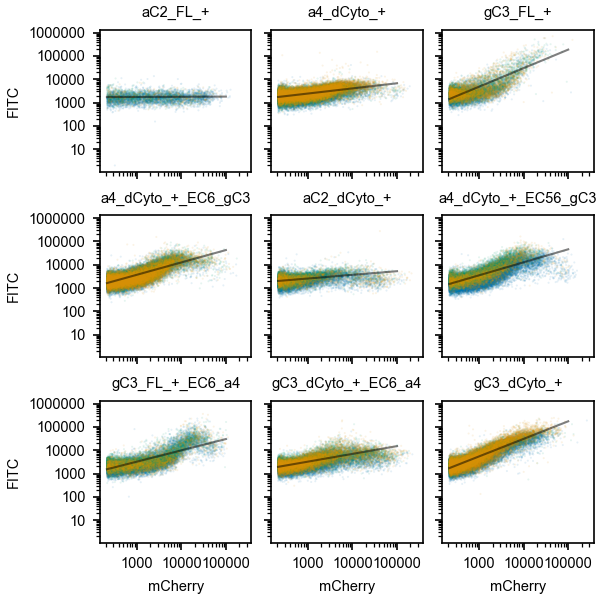

In [14]:
important = [smpl for smpl in data.index.unique('S') if smpl not in controls and 'untransfected_unstained' not in smpl]
fig, axs = plt.subplots(3,3, layout = 'constrained', dpi = 150, sharex = True, sharey = True, figsize = (4, 4))

xlim = [tthr, 100000]
m = E_s['slope']
b = E_s['intercept']

for smplr, axr in zip(np.array(important).reshape(3,3), axs):
    for sample, ax in zip(smplr, axr):
        sns.scatterplot(np.log(transfected.xs(sample, level = 'S')[['mCherry','FITC']]).reset_index(),
                        x = 'mCherry',
                        y = 'FITC', 
                        hue = 'E',
                        palette = sns.color_palette('colorblind')[:3],
                        alpha = 0.1, ec = 'none', ax = ax, s = 1, legend = False)
        ax.plot(np.array(np.log(xlim)), m[sample]*np.array(np.log(xlim))+b[sample], color = 'k', alpha = 0.5, lw = 1)
        ax.set_title(str.join('_', sample.split('_')[:-1]))
        logticks(ax)
plt.show()

In [15]:
m = stained[(stained['mCherry'] > tthr) & (stained['FITC'] > 0)].groupby(list('ES')).apply(lambda x: linregress(np.log(x['mCherry']), np.log(x['FITC'])).slope).groupby('S').mean()
b = stained[(stained['mCherry'] > tthr) & (stained['FITC'] > 0)].groupby(list('ES')).apply(lambda x: linregress(np.log(x['mCherry']), np.log(x['FITC'])).intercept).groupby('S').mean()

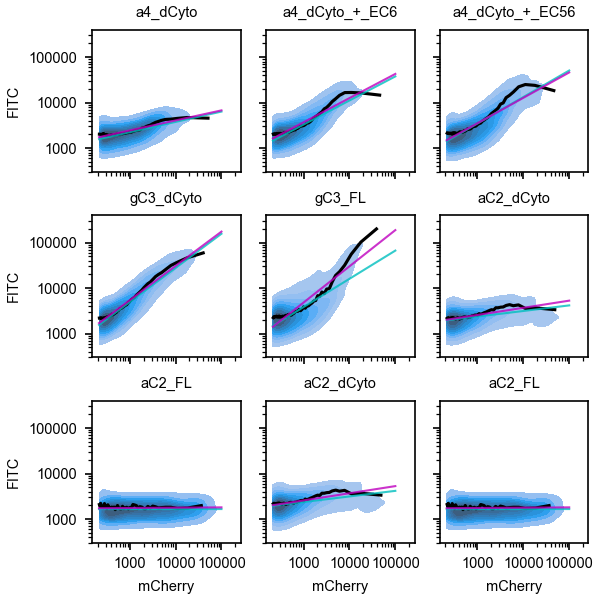

In [16]:
important = [smpl for smpl in stained.index.unique('S') if smpl not in controls and 'untransfected' not in smpl]
important = np.array(important + important[-2:])
plotshape = (3,3)
fig, axs = plt.subplots(*plotshape, layout = 'constrained', dpi = 150, sharex = True, sharey = True, figsize = (4, 4))
for smplr, axr in zip(important.reshape(*plotshape), axs):
    for sample, ax in zip(smplr, axr):
        # ax.semilogx()
        # ax.semilogy()
        # sns.scatterplot(np.log(transfected.xs(sample, level = 'S')),
        #                 x = 'mCherry',
        #                 y = 'FITC', alpha = 0.1, ec = 'none', ax = ax, s = 1, color = 'k')
        sns.kdeplot(np.log(transfected.xs(sample, level = 'S')[['mCherry','FITC']]).reset_index(),
                    x = 'mCherry',
                    y = 'FITC',
                    # hue = 'E',
                    # palette = sns.color_palette('colorblind')[:3],
                    ax = ax,
                    cut = 0, fill = True, legend = False,
                   )
        ax.plot(np.log(bn_es.groupby(list('SB'), observed = False).mean().xs(sample, level = 'S')['FPbin'].to_numpy()),
                np.log(bn_es.groupby(list('SB'), observed = False).mean().xs(sample, level = 'S')['Abbin'].to_numpy()), color = 'k')
        # without bins
        ax.plot(np.array(np.log(xlim)), m[sample]*np.array(np.log(xlim))+b[sample], color = 'c', alpha = 0.8, lw = 1)
        # with bins
        ax.plot(np.array(np.log(xlim)), E_s.at[sample,'slope']*np.array(np.log(xlim))+E_s.at[sample,'intercept'], color = 'm', alpha = 0.8, lw = 1)
        ax.set_title(str.join('_', sample.split('_')[:-2]))
        ax.set_ylim(np.log(300), np.log(400000))
        logticks(ax)
plt.show()

In [17]:
plt.savefig('correlation_bin_no-bin_compare.svg', dpi = 300)

In [18]:
# using_bins = E_es['slope'].groupby('S').mean()
using_bins = E_es['slope']

In [19]:
# no_bins = stained[(stained['mCherry'] > 0) & (stained['FITC'] > 0)].groupby(list('ES')).apply(lambda x: linregress(np.log(x['mCherry']), np.log(x['FITC'])).slope).groupby('S').mean()
no_bins = stained[(stained['mCherry'] > tthr) & (stained['FITC'] > 0)].groupby(list('ES')).apply(lambda x: linregress(np.log(x['mCherry']), np.log(x['FITC'])).slope)

In [20]:
[smpl for smpl in stained.index.unique('S')]
# stained.loc[pd.IndexSlice[:,[smpl for smpl in stained.index.unique('S') if 'EC' in smpl]+['gC3_FL_+_stained'],:]]
subset = [
    'aC2_FL_+_stained',
    'aC2_dCyto_+_stained',
    'gC3_FL_+_stained',
    'gC3_dCyto_+_stained',
    'gC3_FL_+_EC6_a4_stained',
    'gC3_dCyto_+_EC6_a4_stained',
]

In [21]:
using_bins = pd.DataFrame(using_bins, columns = ['slope'])
using_bins['method'] = len(using_bins)*['using bins']

no_bins = pd.DataFrame(no_bins, columns = ['slope'])
no_bins['method'] = len(no_bins)*['direct fit']
no_bins

slope      method
E        S                                                
20241114 a4_dCyto_+_EC56_gC3_stained  0.521505  direct fit
         a4_dCyto_+_EC6_gC3_stained   0.545277  direct fit
         a4_dCyto_+_stained           0.226917  direct fit
         aC2_FL_+_stained             0.033307  direct fit
         aC2_dCyto_+_stained          0.125579  direct fit
         gC3_FL_+_stained             0.617045  direct fit
         gC3_dCyto_+_stained          0.715787  direct fit
20241119 a4_dCyto_+_EC56_gC3_stained  0.606011  direct fit
         a4_dCyto_+_EC6_gC3_stained   0.519560  direct fit
         a4_dCyto_+_stained           0.241437  direct fit
         aC2_FL_+_stained            -0.006688  direct fit
         aC2_dCyto_+_stained          0.085469  direct fit
         gC3_FL_+_stained             0.602855  direct fit
         gC3_dCyto_+_stained          0.796185  direct fit
20241120 a4_dCyto_+_EC56_gC3_stained  0.620610  direct fit
         a4_dCyto_+_EC6_gC3_stained   0.522244  direct fit
         a4_dCyto_+_stained           0.212386  direct fit
         aC2_FL_+_stained            -0.025472  direct fit
         aC2_dCyto_+_stained          0.157587  direct fit
         gC3_FL_+_stained             0.640821  direct fit
         gC3_dCyto_+_stained          0.739162  direct fit

In [22]:
compare = pd.concat([using_bins, no_bins], axis = 0)
compare

slope      method
E        S                                                  
20241114 a4_FL_-_stained                0.049454  using bins
         a4_FL_-_unstained              0.037260  using bins
         a4_dCyto_+_EC56_gC3_stained    0.537077  using bins
         a4_dCyto_+_EC56_gC3_unstained  0.046691  using bins
         a4_dCyto_+_EC6_gC3_stained     0.526176  using bins
...                                          ...         ...
20241120 a4_dCyto_+_stained             0.212386  direct fit
         aC2_FL_+_stained              -0.025472  direct fit
         aC2_dCyto_+_stained            0.157587  direct fit
         gC3_FL_+_stained               0.640821  direct fit
         gC3_dCyto_+_stained            0.739162  direct fit

[91 rows x 2 columns]

In [23]:
stained.index.unique('S')

Index(['a4_dCyto_+_stained', 'a4_dCyto_+_EC6_gC3_stained',
       'a4_dCyto_+_EC56_gC3_stained', 'gC3_dCyto_+_stained',
       'gC3_FL_+_stained', 'aC2_dCyto_+_stained', 'aC2_FL_+_stained'],
      dtype='object', name='S')

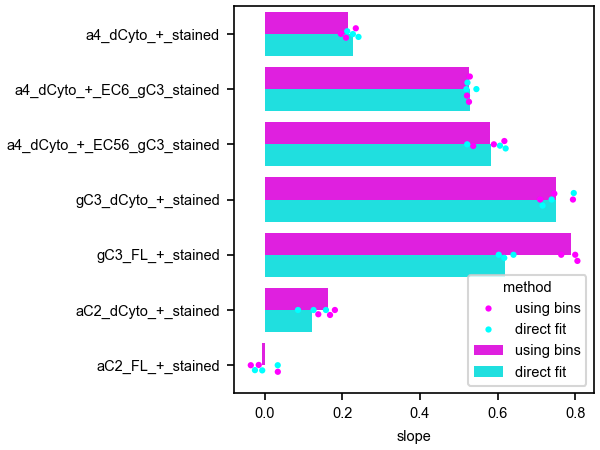

In [24]:
fig, ax = plt.subplots(1,1, layout = 'constrained', figsize = (4,3), dpi = 150)

sns.swarmplot(
    data = compare.loc[pd.IndexSlice[:,stained.index.unique('S')],:].reset_index(),
    x = 'slope',
    y = 'S',
    hue = 'method',
    palette = ['magenta', 'cyan'],
    s = 3,
    ax = ax
)

sns.barplot(
    data = compare.loc[pd.IndexSlice[:,stained.index.unique('S')],:].reset_index(),
    x = 'slope',
    y = 'S',
    hue = 'method',
    palette = ['magenta', 'cyan'],
    errorbar = None,
    ax = ax
)

ax.set_ylabel(None)
plt.show()

In [25]:
second_compare = pd.concat([using_bins['slope'], no_bins['slope']], axis = 1, keys = ['using bins', 'direct fit']).dropna(how = 'any')
second_compare

using bins  direct fit
E        S                                                  
20241114 a4_dCyto_+_EC56_gC3_stained    0.537077    0.521505
         a4_dCyto_+_EC6_gC3_stained     0.526176    0.545277
         a4_dCyto_+_stained             0.209152    0.226917
         aC2_FL_+_stained               0.033513    0.033307
         aC2_dCyto_+_stained            0.137828    0.125579
         gC3_FL_+_stained               0.805600    0.617045
         gC3_dCyto_+_stained            0.709628    0.715787
20241119 a4_dCyto_+_EC56_gC3_stained    0.590257    0.606011
         a4_dCyto_+_EC6_gC3_stained     0.528339    0.519560
         a4_dCyto_+_stained             0.234487    0.241437
         aC2_FL_+_stained              -0.015667   -0.006688
         aC2_dCyto_+_stained            0.168068    0.085469
         gC3_FL_+_stained               0.799917    0.602855
         gC3_dCyto_+_stained            0.794078    0.796185
20241120 a4_dCyto_+_EC56_gC3_stained    0.617355    0.620610
         a4_dCyto_+_EC6_gC3_stained     0.520958    0.522244
         a4_dCyto_+_stained             0.196031    0.212386
         aC2_FL_+_stained              -0.036150   -0.025472
         aC2_dCyto_+_stained            0.180575    0.157587
         gC3_FL_+_stained               0.763840    0.640821
         gC3_dCyto_+_stained            0.746116    0.739162

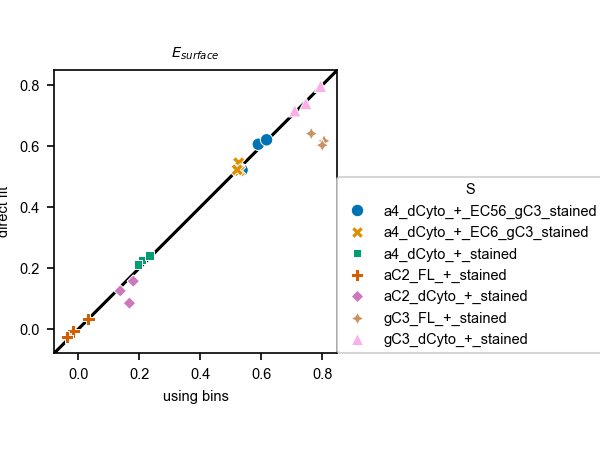

In [26]:
fig, ax = plt.subplots(1,1, layout = 'constrained', figsize = (4,3), dpi = 150,)

sns.scatterplot(
    data = second_compare.reset_index(),
    x = 'using bins',
    y = 'direct fit',
    hue = 'S',
    palette = sns.color_palette('colorblind')[:7],
    style = 'S',
    ax = ax,
)
ax.set_aspect(1)
lims = ax.get_xlim()
ax.plot([-1,1],[-1,1], color = 'k', zorder = -1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title(r'$E_{surface}$')
sns.move_legend(ax, (1,0))
# ax.set_ylabel(None)
plt.show()

plt.savefig('bins_vs_directfit.svg', dpi = 300)

-----------------------------

In [30]:
def reformat_for_dunnett(df, ssel):
    if isinstance(df, pd.DataFrame):
        dtable = df['slope'].loc[pd.IndexSlice[:,ssel]].unstack('S')
    elif isinstance(df, pd.Series):
        dtable = df.loc[pd.IndexSlice[:,ssel]].unstack('S')
    listform = pd.DataFrame(columns = dtable[ssel].columns)
    for col in dtable[ssel]:
        reform = [dtable[col].dropna(how = 'any').values]
        listform[col] = reform
    listform = listform.rename(index = {0 : 'values'})
    return listform.loc['values'].loc[ssel]

In [32]:
reformat_for_dunnett(sde_es, subset)

S
aC2_FL_+_stained              [0.012195121951219513, 0.01791044776119403, 0....
aC2_dCyto_+_stained           [0.05639602542297019, 0.09903047091412742, 0.1...
gC3_FL_+_stained              [0.18684985279685967, 0.2937326956959476, 0.27...
gC3_dCyto_+_stained           [0.36661866900394413, 0.4646178436501017, 0.39...
gC3_FL_+_EC6_a4_stained       [0.24830988488945735, 0.29732620320855613, 0.2...
gC3_dCyto_+_EC6_a4_stained    [0.18312146892655368, 0.30415152516242705, 0.3...
Name: values, dtype: object

In [33]:
from scipy.stats import tukey_hsd

In [55]:
res = tukey_hsd(*reformat_for_dunnett(sde_es, stained.index.unique('S')).values).pvalue
pd.DataFrame(data = res, columns = stained.index.unique('S'), index = stained.index.unique('S')).to_csv('./S3_flow_sde_es.csv')
res = tukey_hsd(*reformat_for_dunnett(ab_es, stained.index.unique('S')).values).pvalue
pd.DataFrame(data = res, columns = stained.index.unique('S'), index = stained.index.unique('S')).to_csv('./S3_flow_ab_es.csv')
res = tukey_hsd(*reformat_for_dunnett(E_es, stained.index.unique('S')).values).pvalue
pd.DataFrame(data = res, columns = stained.index.unique('S'), index = stained.index.unique('S')).to_csv('./S3_flow_E_es.csv')

In [43]:
from scipy.stats import dunnett

In [52]:
ctrl = 'a4_dCyto_+_stained'
smpllst = [smpl for smpl in stained.index.unique('S') if smpl != ctrl]
res = dunnett(
    *list(reformat_for_dunnett(sde_es, smpllst)), 
    control = sde_es.loc[pd.IndexSlice[:,ctrl]],
    alternative = 'greater').pvalue
pd.Series(res, index = smpllst)

a4_dCyto_+_EC6_gC3_stained     0.001087
a4_dCyto_+_EC56_gC3_stained    0.000062
gC3_dCyto_+_stained            0.000020
gC3_FL_+_stained               0.007201
aC2_dCyto_+_stained            0.967512
aC2_FL_+_stained               0.999814
dtype: float64

In [53]:
ctrl = 'a4_dCyto_+_stained'
smpllst = [smpl for smpl in stained.index.unique('S') if smpl != ctrl]
res = dunnett(
    *list(reformat_for_dunnett(ab_es, smpllst)), 
    control = ab_es.loc[pd.IndexSlice[:,ctrl]],
    alternative = 'greater').pvalue
pd.Series(res, index = smpllst)

a4_dCyto_+_EC6_gC3_stained     0.108060
a4_dCyto_+_EC56_gC3_stained    0.008001
gC3_dCyto_+_stained            0.000066
gC3_FL_+_stained               0.000772
aC2_dCyto_+_stained            0.864299
aC2_FL_+_stained               0.978757
dtype: float64

In [54]:
ctrl = 'a4_dCyto_+_stained'
smpllst = [smpl for smpl in stained.index.unique('S') if smpl != ctrl]
res = dunnett(
    *list(reformat_for_dunnett(E_es, smpllst)), 
    control = E_es.loc[pd.IndexSlice[:,ctrl],'slope'],
    alternative = 'greater').pvalue
pd.Series(res, index = smpllst)

a4_dCyto_+_EC6_gC3_stained     4.539791e-11
a4_dCyto_+_EC56_gC3_stained    1.898481e-14
gC3_dCyto_+_stained            0.000000e+00
gC3_FL_+_stained               0.000000e+00
aC2_dCyto_+_stained            9.994713e-01
aC2_FL_+_stained               1.000000e+00
dtype: float64